In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Pre-processing

In [2]:
import numpy as np
import pandas as pd

from IPython.display import display, HTML
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.io as pio


import seaborn as sns
from importlib import reload
import matplotlib.pyplot as plt
import matplotlib
import warnings

# Configure Jupyter Notebook
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 500)
pd.set_option('display.expand_frame_repr', False)
# pd.set_option('max_colwidth', -1)
display(HTML("<style>div.output_scroll { height: 35em; }</style>"))

reload(plt)
%matplotlib inline
%config InlineBackend.figure_format ='retina'

warnings.filterwarnings('ignore')

# configure plotly graph objects
pio.renderers.default = 'iframe'
# pio.renderers.default = 'vscode'

pio.templates["ck_template"] = go.layout.Template(
    layout_colorway = px.colors.sequential.Viridis,
#     layout_hovermode = 'closest',
#     layout_hoverdistance = -1,
    layout_autosize=False,
    layout_width=800,
    layout_height=600,
    layout_font = dict(family="Calibri Light"),
    layout_title_font = dict(family="Calibri"),
    layout_hoverlabel_font = dict(family="Calibri Light"),
#     plot_bgcolor="white",
)

# pio.templates.default = 'seaborn+ck_template+gridon'
pio.templates.default = 'ck_template+gridon'
# pio.templates.default = 'seaborn+gridon'
# pio.templates

In [3]:
index_names = ['engine', 'cycle']
setting_names = ['setting_1', 'setting_2', 'setting_3']
sensor_names=[ "(Fan inlet temperature) (◦R)",
"(LPC outlet temperature) (◦R)",
"(HPC outlet temperature) (◦R)",
"(LPT outlet temperature) (◦R)",
"(Fan inlet Pressure) (psia)",
"(bypass-duct pressure) (psia)",
"(HPC outlet pressure) (psia)",
"(Physical fan speed) (rpm)",
"(Physical core speed) (rpm)",
"(Engine pressure ratio(P50/P2)",
"(HPC outlet Static pressure) (psia)",
"(Ratio of fuel flow to Ps30) (pps/psia)",
"(Corrected fan speed) (rpm)",
"(Corrected core speed) (rpm)",
"(Bypass Ratio) ",
"(Burner fuel-air ratio)",
"(Bleed Enthalpy)",
"(Required fan speed)",
"(Required fan conversion speed)",
"(High-pressure turbines Cool air flow)",
"(Low-pressure turbines Cool air flow)" ]
col_names = index_names + setting_names + sensor_names

In [4]:
print('Listing contents of drive/MyDrive/archive/CMaps/ to verify file paths:')
!ls -F "drive/MyDrive/archive/CMaps/"

df_train = pd.read_csv('drive/MyDrive/CMaps/train_FD004.txt',sep=r'\s+',header=None,index_col=False,names=col_names)
df_test = pd.read_csv('drive/MyDrive/CMaps/test_FD004.txt',sep=r'\s+',header=None,index_col=False,names=col_names)
df_test_RUL = pd.read_csv('drive/MyDrive/CMaps/RUL_FD004.txt',sep=r'\s+',header=None,index_col=False,names=['RUL'])

Listing contents of drive/MyDrive/archive/CMaps/ to verify file paths:
ls: cannot access 'drive/MyDrive/archive/CMaps/': No such file or directory


In [5]:

# corr = df_train.corr()
# mask = np.triu(np.ones_like(corr, dtype=bool))

# f, ax = plt.subplots(figsize=(20, 20))
# cmap = sns.diverging_palette(230, 10, as_cmap=True)

# # Draw the heatmap with annotation
# sns.heatmap(
#     corr,
#     mask=mask,
#     cmap=cmap,
#     vmax=.3,
#     center=0,
#     square=True,
#     linewidths=.5,
#     cbar_kws={"shrink": .5},
#     annot=True,           # <- Add this line
#     fmt=".1f"             # <- Format the numbers to 2 decimal places
# )

# plt.show()


In [6]:
# sens_const_values = []
# for feature in list(setting_names + sensor_names):
#     try:
#         if df_train[feature].min()==df_train[feature].max():
#             sens_const_values.append(feature)
#     except:
#         pass

# print(sens_const_values)
# df_train.drop(sens_const_values,axis=1,inplace=True)
# df_test.drop(sens_const_values,axis=1,inplace=True)

In [7]:
# cor_matrix = df_train.corr().abs()
# upper_tri = cor_matrix.where(np.triu(np.ones(cor_matrix.shape),k=1).astype(np.bool))
# corr_features = [column for column in upper_tri.columns if any(upper_tri[column] > 0.95)]
# print(corr_features)
# df_train.drop(corr_features,axis=1,inplace=True)
# df_test.drop(corr_features,axis=1,inplace=True)

In [8]:
features = list(df_train.columns)

In [9]:
df_train.head()

,engine,cycle,setting_1,setting_2,setting_3,(Fan inlet temperature) (◦R),(LPC outlet temperature) (◦R),(HPC outlet temperature) (◦R),(LPT outlet temperature) (◦R),(Fan inlet Pressure) (psia),(bypass-duct pressure) (psia),(HPC outlet pressure) (psia),(Physical fan speed) (rpm),(Physical core speed) (rpm),(Engine pressure ratio(P50/P2),(HPC outlet Static pressure) (psia),(Ratio of fuel flow to Ps30) (pps/psia),(Corrected fan speed) (rpm),(Corrected core speed) (rpm),(Bypass Ratio),(Burner fuel-air ratio),(Bleed Enthalpy),(Required fan speed),(Required fan conversion speed),(High-pressure turbines Cool air flow),(Low-pressure turbines Cool air flow)
0,1,1,42.0049,0.8400,100.0,445.00,549.68,1343.43,1112.93,3.91,5.70,137.36,2211.86,8311.32,1.01,41.69,129.78,2387.99,8074.83,9.3335,0.02,330,2212,100.00,10.62,6.3670
1,1,2,20.0020,0.7002,100.0,491.19,606.07,1477.61,1237.50,9.35,13.61,332.10,2323.66,8713.60,1.07,43.94,312.59,2387.73,8046.13,9.1913,0.02,361,2324,100.00,24.37,14.6552
2,1,3,42.0038,0.8409,100.0,445.00,548.95,1343.12,1117.05,3.91,5.69,138.18,2211.92,8306.69,1.01,41.66,129.62,2387.97,8066.62,9.4007,0.02,329,2212,100.00,10.48,6.4213
3,1,4,42.0000,0.8400,100.0,445.00,548.70,1341.24,1118.03,3.91,5.70,137.98,2211.88,8312.35,1.02,41.68,129.80,2388.02,8076.05,9.3369,0.02,328,2212,100.00,10.54,6.4176
4,1,5,25.0063,0.6207,60.0,462.54,536.10,1255.23,1033.59,7.05,9.00,174.82,1915.22,7994.94,0.93,36.48,164.11,2028.08,7865.80,10.8366,0.02,305,1915,84.93,14.03,8.6754


In [10]:
# # check for missing data
# for feature in features:
#     print(feature + " - " + str(len(df_train[df_train[feature].isna()])))

In [11]:
# define the maximum life of each engine, as this could be used to obtain the RUL at each point in time of the engine's life
df_train_RUL = df_train.groupby(['engine']).agg({'cycle':'max'})
df_train_RUL.rename(columns={'cycle':'life'},inplace=True)
df_train_RUL.head()

,life
engine,
1,321
2,299
3,307
4,274
5,193


In [12]:
df_train=df_train.merge(df_train_RUL,how='left',on=['engine'])

In [13]:
!pip install mlxtend

✅ Discretization complete
   Features discretized: 25
        setting_1       setting_2      setting_3
0  setting_1_HIGH  setting_2_HIGH  setting_3_LOW
1   setting_1_MED   setting_2_MED  setting_3_LOW
2  setting_1_HIGH  setting_2_HIGH  setting_3_LOW

✅ RUL States distribution:
RUL_STATE
RUL_HEALTHY      42325
RUL_DEGRADING    11205
RUL_CRITICAL      7719
Name: count, dtype: int64

✅ Transaction matrix shape: (61249, 71)
   Total unique items: 71

⚙️  Mining with: support≥0.05, confidence≥0.6, lift≥1.2
✅ Frequent itemsets found: 18143
       support                                           itemsets  length
70    1.000000                                    (setting_3_LOW)       1
5011  1.000000  (Required fan_LOW, Burner fuel-_LOW, setting_3...       3
264   1.000000                  (Burner fuel-_LOW, setting_3_LOW)       2
1654  1.000000                  (Required fan_LOW, setting_3_LOW)       2
56    1.000000                                 (Required fan_LOW)       1
3     1.000000  

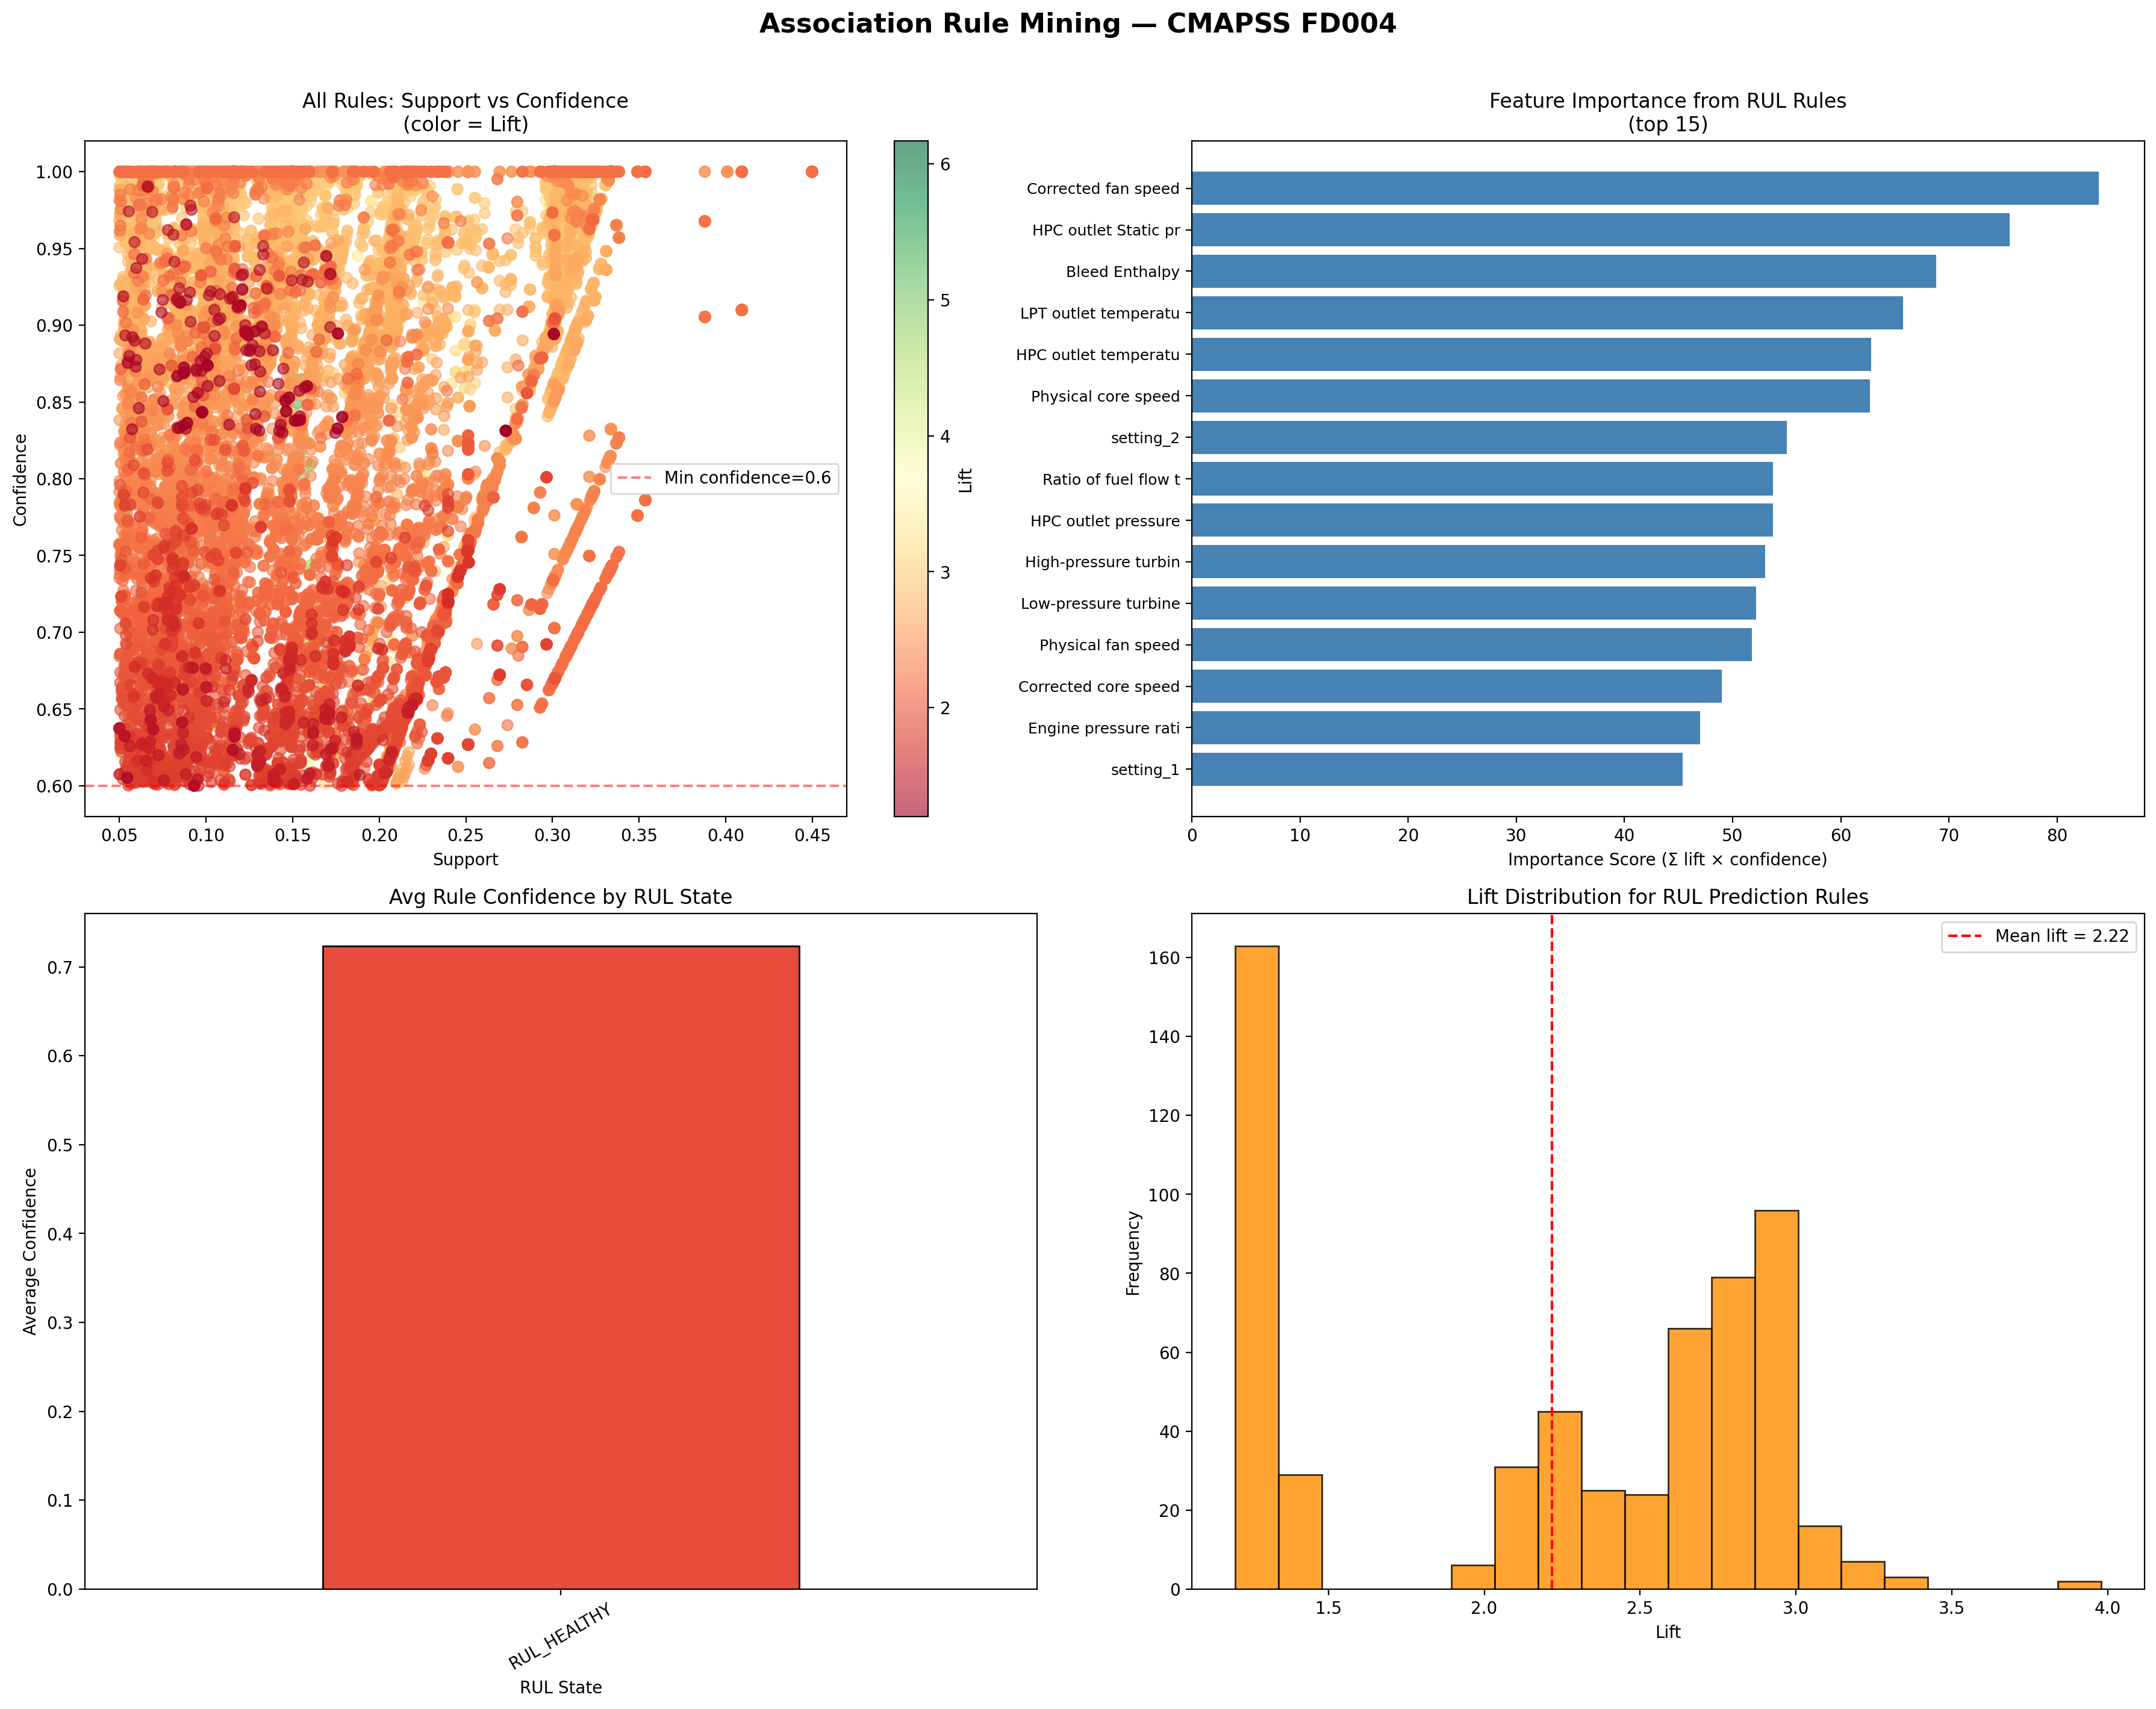

✅ Plot saved as 'association_rules_analysis.png'

📋 FEATURE SELECTION SUMMARY

✅ SELECTED FEATURES (score ≥ mean=46.58):
    1. Corrected fan speed                  score=83.874
    2. HPC outlet Static pressure           score=75.597
    3. Bleed Enthalpy                       score=68.799
    4. LPT outlet temperature               score=65.764
    5. HPC outlet temperature               score=62.784
    6. Physical core speed                  score=62.710
    7. setting_2                            score=54.991
    8. Ratio of fuel flow to Ps30           score=53.755
    9. HPC outlet pressure                  score=53.734
   10. High-pressure turbines Cool air flow  score=53.031
   11. Low-pressure turbines Cool air flow  score=52.149
   12. Physical fan speed                   score=51.798
   13. Corrected core speed                 score=48.986
   14. Engine pressure ratio                score=46.970

❌ DROPPED FEATURES (score < 46.58):
       setting_1                           

In [14]:
# ============================================================
# ASSOCIATION RULE MINING FOR FEATURE SELECTION
# CMAPSS Turbofan Engine Dataset
# ============================================================

import pandas as pd
import numpy as np
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import KBinsDiscretizer
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# STEP 1: DISCRETIZE CONTINUOUS FEATURES INTO BINS
# Association rule mining requires categorical/binary data
# ============================================================

def discretize_features(df, n_bins=3, cols_to_skip=['engine', 'cycle', 'RUL']):
    """
    Discretize continuous features into labeled bins.
    n_bins=3 → LOW / MEDIUM / HIGH for each feature
    """
    df_disc = df.copy()
    bin_labels = {3: ['LOW', 'MED', 'HIGH'],
                  4: ['LOW', 'MED-LOW', 'MED-HIGH', 'HIGH'],
                  5: ['VERY-LOW', 'LOW', 'MED', 'HIGH', 'VERY-HIGH']}

    sensor_cols = [c for c in df.columns if c not in cols_to_skip]

    est = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy='quantile')
    disc_array = est.fit_transform(df[sensor_cols])

    for i, col in enumerate(sensor_cols):
        short_name = col.split('(')[1].split(')')[0][:12].strip() if '(' in col else col[:12]
        labels = bin_labels[n_bins]
        df_disc[col] = [f"{short_name}_{labels[int(v)]}" for v in disc_array[:, i]]

    return df_disc, sensor_cols

df_disc, sensor_cols = discretize_features(df_train, n_bins=3)
print("✅ Discretization complete")
print(f"   Features discretized: {len(sensor_cols)}")
print(df_disc[sensor_cols[:3]].head(3))


# ============================================================
# STEP 2: ALSO DISCRETIZE RUL INTO HEALTH STATES
# This lets us mine rules like "sensor X HIGH → RUL CRITICAL"
# ============================================================

# Fix: Calculate RUL for df_train before using it
df_train['RUL'] = df_train['life'] - df_train['cycle']

def label_rul(rul):
    if rul <= 30:   return 'RUL_CRITICAL'    # <30 cycles left
    elif rul <= 75: return 'RUL_DEGRADING'   # 30–75 cycles left
    else:           return 'RUL_HEALTHY'     # >75 cycles left

df_disc['RUL_STATE'] = df_train['RUL'].apply(label_rul)
rul_value_counts = df_disc['RUL_STATE'].value_counts()
print("\n✅ RUL States distribution:")
print(rul_value_counts)


# ============================================================
# STEP 3: CREATE ONE-HOT ENCODED TRANSACTION MATRIX
# mlxtend's apriori needs a boolean DataFrame
# ============================================================

transaction_cols = sensor_cols + ['RUL_STATE']  # include RUL state as an item

# Build transaction list: each row = set of "items" (discretized values)
transactions = df_disc[transaction_cols].values.tolist()

te = TransactionEncoder()
te_array = te.fit_transform(transactions)
df_onehot = pd.DataFrame(te_array, columns=te.columns_)

print(f"\n✅ Transaction matrix shape: {df_onehot.shape}")
print(f"   Total unique items: {len(df_onehot.columns)}")


# ============================================================
# STEP 4: MINE FREQUENT ITEMSETS WITH APRIORI
# ============================================================

MIN_SUPPORT = 0.05   # item appears in at least 5% of rows
MIN_CONFIDENCE = 0.6  # rule fires correctly 60% of the time
MIN_LIFT = 1.2        # rule is at least 1.2x better than random

print(f"\n⚙️  Mining with: support≥{MIN_SUPPORT}, confidence≥{MIN_CONFIDENCE}, lift≥{MIN_LIFT}")

frequent_itemsets = apriori(
    df_onehot,
    min_support=MIN_SUPPORT,
    use_colnames=True,
    max_len=3          # max 3-item combinations (keeps it manageable)
)

frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)
print(f"✅ Frequent itemsets found: {len(frequent_itemsets)}")
print(frequent_itemsets.sort_values('support', ascending=False).head(10))


# ============================================================
# STEP 5: GENERATE ASSOCIATION RULES
# ============================================================

rules = association_rules(
    frequent_itemsets,
    metric='confidence',
    min_threshold=MIN_CONFIDENCE
)

# Filter by lift as well
rules = rules[rules['lift'] >= MIN_LIFT].copy()
rules = rules.sort_values(['lift', 'confidence'], ascending=False).reset_index(drop=True)

print(f"\n✅ Association rules generated: {len(rules)}")
print("\nTop 20 Rules (sorted by lift):")
print(rules[['antecedents','consequents','support','confidence','lift']].head(20).to_string())


# ============================================================
# STEP 6: FILTER RULES INVOLVING RUL_STATE (KEY FOR FEATURE SELECTION)
# These tell you WHICH sensors strongly predict engine health
# ============================================================

rul_rules = rules[
    rules['consequents'].apply(lambda x: any('RUL_' in str(item) for item in x))
].copy()

print(f"\n🎯 Rules with RUL_STATE as consequent: {len(rul_rules)}")
print("\nRules predicting RUL state (sorted by lift):")
print(rul_rules[['antecedents','consequents','support','confidence','lift']].head(30).to_string())


# ============================================================
# STEP 7: COMPUTE FEATURE IMPORTANCE FROM RULES
# Features that appear most in high-lift RUL rules = most important
# ============================================================

def extract_feature_importance(rul_rules, sensor_cols):
    """
    Score each sensor by how often it appears in high-lift rules
    predicting RUL state, weighted by lift × confidence.
    """
    feature_scores = {}

    # Map item names back to original sensor names
    short_to_full = {}
    for col in sensor_cols:
        short = col.split('(')[1].split(')')[0][:12].strip() if '(' in col else col[:12]
        short_to_full[short] = col

    for _, row in rul_rules.iterrows():
        weight = row['lift'] * row['confidence']
        for item in row['antecedents']:
            # Extract the base feature name (remove _LOW/_MED/_HIGH suffix)
            parts = item.rsplit('_', 1)
            if len(parts) == 2:
                base = parts[0]
                if base in short_to_full:
                    full_name = short_to_full[base]
                    feature_scores[full_name] = feature_scores.get(full_name, 0) + weight

    scores_df = pd.DataFrame.from_dict(feature_scores, orient='index', columns=['importance_score'])
    scores_df = scores_df.sort_values('importance_score', ascending=False)
    return scores_df

feature_importance = extract_feature_importance(rul_rules, sensor_cols)

print("\n🏆 Feature Importance Scores (from association rules):")
print(feature_importance.to_string())


# ============================================================
# STEP 8: VISUALIZATIONS
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Association Rule Mining — CMAPSS FD004', fontsize=16, fontweight='bold', y=1.01)

# --- Plot 1: Support vs Confidence scatter (all rules) ---
ax1 = axes[0, 0]
scatter = ax1.scatter(
    rules['support'], rules['confidence'],
    c=rules['lift'], cmap='RdYlGn', alpha=0.6, s=40
)
plt.colorbar(scatter, ax=ax1, label='Lift')
ax1.set_xlabel('Support')
ax1.set_ylabel('Confidence')
ax1.set_title('All Rules: Support vs Confidence\n(color = Lift)')
ax1.axhline(MIN_CONFIDENCE, color='red', linestyle='--', alpha=0.5, label=f'Min confidence={MIN_CONFIDENCE}')
ax1.legend()

# --- Plot 2: Feature Importance Bar Chart ---
ax2 = axes[0, 1]
if not feature_importance.empty:
    top_n = feature_importance.head(15)
    # Shorten names for display
    short_names = [col.split('(')[1].split(')')[0][:20].strip() if '(' in col else col[:20]
                   for col in top_n.index]
    bars = ax2.barh(range(len(top_n)), top_n['importance_score'].values, color='steelblue')
    ax2.set_yticks(range(len(top_n)))
    ax2.set_yticklabels(short_names, fontsize=9)
    ax2.invert_yaxis()
    ax2.set_xlabel('Importance Score (Σ lift × confidence)')
    ax2.set_title('Feature Importance from RUL Rules\n(top 15)')
else:
    ax2.text(0.5, 0.5, 'No RUL rules found\n(try lowering min_support)',
             ha='center', va='center', transform=ax2.transAxes)

# --- Plot 3: RUL-specific rules — Confidence by RUL state ---
ax3 = axes[1, 0]
if not rul_rules.empty:
    rul_rules['rul_state'] = rul_rules['consequents'].apply(
        lambda x: [i for i in x if 'RUL_' in str(i)][0]
    )
    rul_rules.groupby('rul_state')['confidence'].mean().plot(
        kind='bar', ax=ax3, color=['#e74c3c', '#f39c12', '#27ae60'], edgecolor='black'
    )
    ax3.set_title('Avg Rule Confidence by RUL State')
    ax3.set_xlabel('RUL State')
    ax3.set_ylabel('Average Confidence')
    ax3.tick_params(axis='x', rotation=30)

# --- Plot 4: Lift distribution for RUL rules ---
ax4 = axes[1, 1]
if not rul_rules.empty:
    ax4.hist(rul_rules['lift'], bins=20, color='darkorange', edgecolor='black', alpha=0.8)
    ax4.axvline(rul_rules['lift'].mean(), color='red', linestyle='--', label=f"Mean lift = {rul_rules['lift'].mean():.2f}")
    ax4.set_xlabel('Lift')
    ax4.set_ylabel('Frequency')
    ax4.set_title('Lift Distribution for RUL Prediction Rules')
    ax4.legend()

plt.tight_layout()
plt.savefig('association_rules_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved as 'association_rules_analysis.png'")


# ============================================================
# STEP 9: RECOMMENDED FEATURE SELECTION THRESHOLD
# ============================================================

print("\n" + "="*60)
print("📋 FEATURE SELECTION SUMMARY")
print("="*60)

if not feature_importance.empty:
    threshold = feature_importance['importance_score'].mean()
    selected = feature_importance[feature_importance['importance_score'] >= threshold]
    dropped  = feature_importance[feature_importance['importance_score'] < threshold]

    print(f"\n✅ SELECTED FEATURES (score ≥ mean={threshold:.2f}):")
    for i, (col, row) in enumerate(selected.iterrows(), 1):
        short = col.split('(')[1].split(')')[0].strip() if '(' in col else col
        print(f"   {i:2d}. {short:<35s}  score={row['importance_score']:.3f}")

    print(f"\n❌ DROPPED FEATURES (score < {threshold:.2f}):")
    for col, row in dropped.iterrows():
        short = col.split('(')[1].split(')')[0].strip() if '(' in col else col
        print(f"       {short:<35s}  score={row['importance_score']:.3f}")

    selected_feature_list = list(selected.index)
    print(f"\n🎯 Use these {len(selected_feature_list)} features in your model:")
    print(selected_feature_list)

In [15]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# The create_sequences function defined here is local and not used globally,
# as it's redefined and used in cell Yh3fWorhDqX6. This definition can be removed.

# First, define the list of selected features based on the previous cell's output
selected_feature_list = [
    '(Corrected fan speed) (rpm)', '(HPC outlet Static pressure) (psia)', '(Bleed Enthalpy)',
    '(LPT outlet temperature) (◦R)', '(HPC outlet temperature) (◦R)', '(Physical core speed) (rpm)',
    'setting_2', '(Ratio of fuel flow to Ps30) (pps/psia)', '(HPC outlet pressure) (psia)',
    '(High-pressure turbines Cool air flow)', '(Low-pressure turbines Cool air flow)',
    '(Physical fan speed) (rpm)', '(Corrected core speed) (rpm)', '(Engine pressure ratio(P50/P2)'
]

# Define columns that should be present in the final DataFrame for training and testing
# 'RUL' is present in df_train but not in the raw df_test
train_final_cols = ['engine', 'cycle', 'RUL'] + selected_feature_list
test_final_cols = ['engine', 'cycle'] + selected_feature_list

# Filter df_train and df_test to include only selected features and identifiers
df_train_filtered = df_train[train_final_cols].copy()
df_test_filtered = df_test[test_final_cols].copy()

# --- Handle NaN and Constant Features ---
# Check for NaNs and impute with mean (as a robust default, can be replaced with median/mode)
for col in selected_feature_list:
    if df_train_filtered[col].isnull().any():
        print(f"Warning: NaNs found in df_train_filtered column '{col}'. Imputing with mean.")
        df_train_filtered[col].fillna(df_train_filtered[col].mean(), inplace=True)
    if df_test_filtered[col].isnull().any():
        print(f"Warning: NaNs found in df_test_filtered column '{col}'. Imputing with mean.")
        df_test_filtered[col].fillna(df_test_filtered[col].mean(), inplace=True)

# Identify and remove constant features from the selected list
constant_features_to_remove = []
for col in selected_feature_list:
    if df_train_filtered[col].nunique() == 1: # Check if all values are identical in training data
        constant_features_to_remove.append(col)
        print(f"Removing constant feature: '{col}' from selected_feature_list.")

if constant_features_to_remove:
    selected_feature_list = [f for f in selected_feature_list if f not in constant_features_to_remove]
    # Drop these columns from the filtered dataframes if they were included
    df_train_filtered.drop(columns=constant_features_to_remove, inplace=True, errors='ignore')
    df_test_filtered.drop(columns=constant_features_to_remove, inplace=True, errors='ignore')

# --- End NaN and Constant Features Handling ---

# Scale only the *remaining* selected features in the filtered DataFrames
scaler = StandardScaler()

df_train_filtered[selected_feature_list] = scaler.fit_transform(df_train_filtered[selected_feature_list])
df_test_filtered[selected_feature_list] = scaler.transform(df_test_filtered[selected_feature_list])

# Update the global df_train and df_test with the filtered and scaled versions
df_train = df_train_filtered
df_test = df_test_filtered

# Final check for NaNs after scaling, just to be sure
if df_train[selected_feature_list].isnull().sum().sum() > 0:
    raise ValueError("ERROR: NaNs still present in df_train after all preprocessing steps.")
if df_test[selected_feature_list].isnull().sum().sum() > 0:
    raise ValueError("ERROR: NaNs still present in df_test after all preprocessing steps.")


  Cap=75     → Test RMSE = 49.21
  Cap=100    → Test RMSE = 38.66
  Cap=110    → Test RMSE = 36.08
  Cap=125    → Test RMSE = 33.54
  Cap=150    → Test RMSE = 33.64
  Cap=175    → Test RMSE = 36.04
  Cap=200    → Test RMSE = 39.62
  Cap=None   → Test RMSE = 52.64


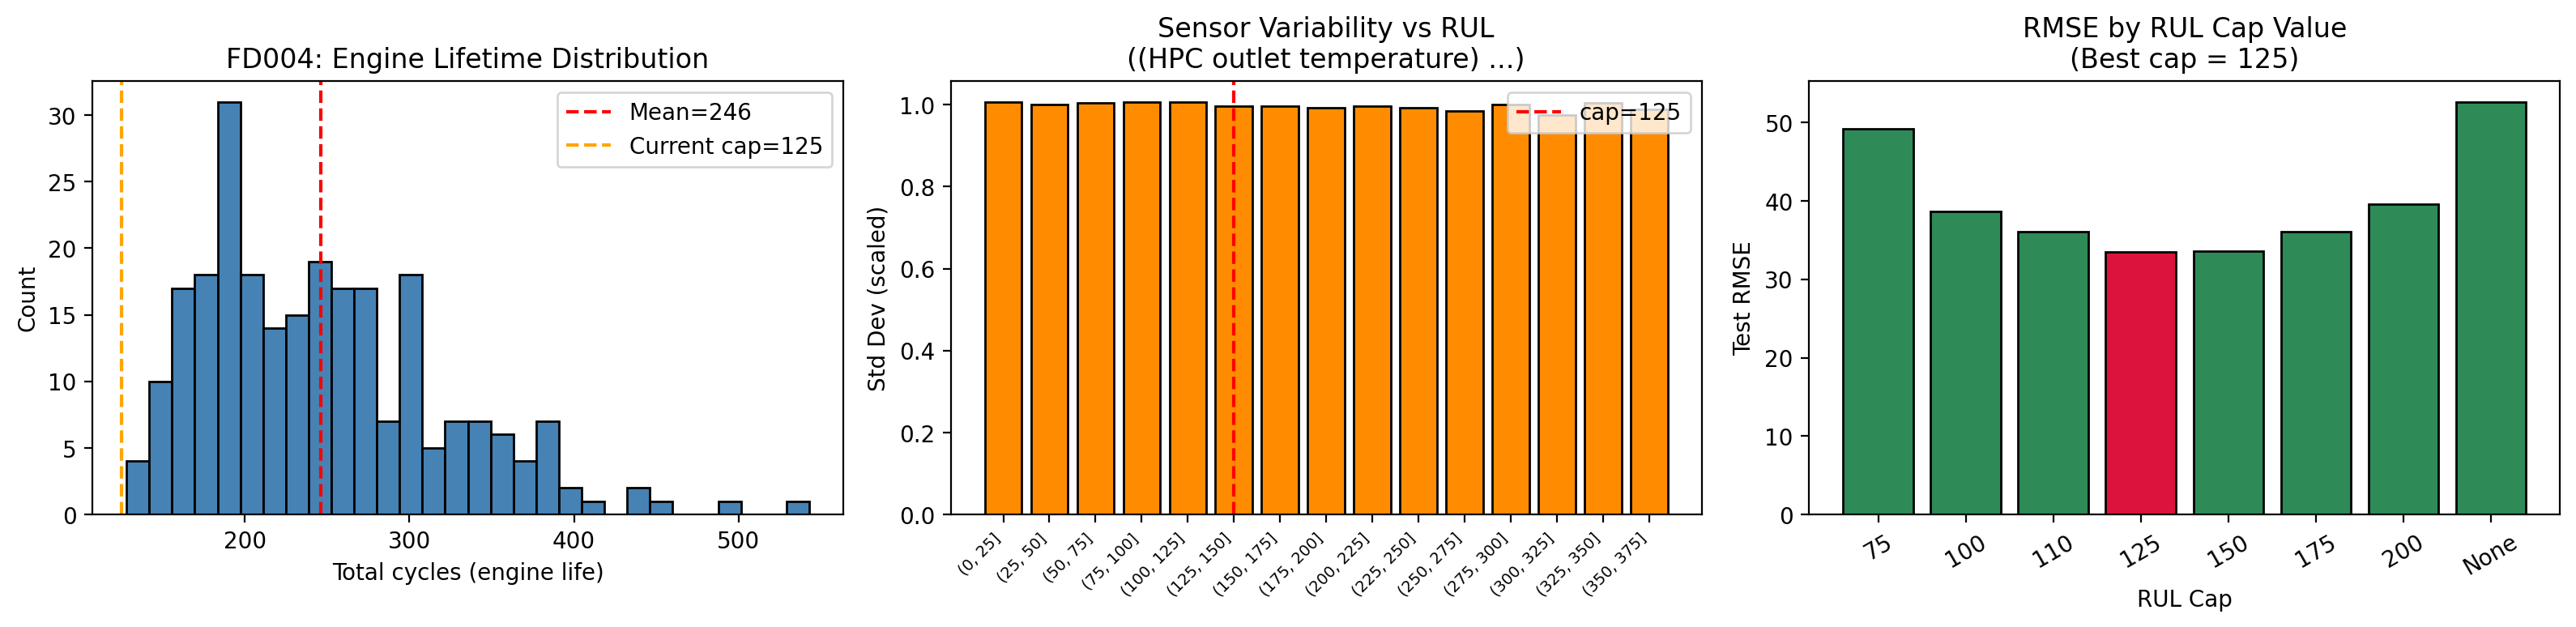


✅ Recommended cap value: 125
   → Update OPTIMAL_CAP below before proceeding


In [16]:
# ============================================================
# RUL CAP ANALYSIS — Run BEFORE capping to find optimal value
# ============================================================
# NOTE: df_train is already scaled at this point, so we use
# a fresh copy from raw data just for this analysis cell only

import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

engine_lives = df_train.groupby('engine')['cycle'].max()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Plot 1: Engine lifetime distribution
axes[0].hist(engine_lives.values, bins=30, color='steelblue', edgecolor='black')
axes[0].axvline(engine_lives.mean(), color='red', linestyle='--',
                label=f'Mean={engine_lives.mean():.0f}')
axes[0].axvline(125, color='orange', linestyle='--', label='Current cap=125')
axes[0].set_title('FD004: Engine Lifetime Distribution')
axes[0].set_xlabel('Total cycles (engine life)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Plot 2: Sensor variability vs RUL
# Use the scaled sensor column name
sensor_to_check = "(HPC outlet temperature) (◦R)"

df_train_temp = df_train.copy()
df_train_temp['RUL_raw'] = df_train_temp.groupby('engine')['cycle'].transform('max') - df_train_temp['cycle']
df_train_temp['RUL_bin'] = pd.cut(df_train_temp['RUL_raw'], bins=range(0, 400, 25))
sensor_std = df_train_temp.groupby('RUL_bin', observed=True)[sensor_to_check].std()

axes[1].bar(range(len(sensor_std)), sensor_std.values, color='darkorange', edgecolor='black')
axes[1].set_xticks(range(len(sensor_std)))
axes[1].set_xticklabels([str(b) for b in sensor_std.index], rotation=45, ha='right', fontsize=7)
axes[1].set_title(f'Sensor Variability vs RUL\n({sensor_to_check[:25]}...)')
axes[1].set_ylabel('Std Dev (scaled)')
axes[1].axvline(125 // 25, color='red', linestyle='--', label='cap=125')
axes[1].legend()

# Plot 3: Cap sweep — uses already-scaled features in df_train
# We only test last-cycle predictions for each test engine
quick_features = [f for f in selected_feature_list if f in df_train.columns][:5]

df_test_temp = df_test.copy()
last_cycles = df_test_temp.groupby('engine')['cycle'].max().reset_index()
last_cycles.rename(columns={'cycle': 'max_cycle'}, inplace=True)
df_test_temp = df_test_temp.merge(last_cycles, on='engine')
test_last = df_test_temp[df_test_temp['cycle'] == df_test_temp['max_cycle']].copy()
test_last = test_last.reset_index(drop=True)
test_last['true_RUL'] = df_test_RUL['RUL'].values

cap_values = [75, 100, 110, 125, 150, 175, 200, None]
rmse_results = []

for cap in cap_values:
    df_tr = df_train.copy()
    max_cycles = df_tr.groupby('engine')['cycle'].transform('max')
    df_tr['RUL_raw'] = max_cycles - df_tr['cycle']
    df_tr['RUL_capped'] = df_tr['RUL_raw'].clip(upper=cap) if cap else df_tr['RUL_raw']

    rf = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
    rf.fit(df_tr[quick_features], df_tr['RUL_capped'])

    preds = rf.predict(test_last[quick_features])
    rmse = np.sqrt(mean_squared_error(test_last['true_RUL'], preds))
    rmse_results.append({'cap': str(cap), 'rmse': rmse})
    print(f"  Cap={str(cap):<6} → Test RMSE = {rmse:.2f}")

results_df = pd.DataFrame(rmse_results)
bars = axes[2].bar(results_df['cap'], results_df['rmse'], color='seagreen', edgecolor='black')
best_idx = results_df['rmse'].idxmin()
best_cap = results_df.loc[best_idx, 'cap']
bars[best_idx].set_facecolor('crimson')
axes[2].set_title(f'RMSE by RUL Cap Value\n(Best cap = {best_cap})')
axes[2].set_xlabel('RUL Cap')
axes[2].set_ylabel('Test RMSE')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('rul_cap_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Recommended cap value: {best_cap}")
print("   → Update OPTIMAL_CAP below before proceeding")

In [17]:
# ============================================================
# APPLY OPTIMAL RUL CAP + SEQUENCE CREATION
# ============================================================

# ── Update this based on cap sweep results above ──
OPTIMAL_CAP = 125   # ← change after reviewing Plot 3

# Apply cap to training RUL
df_train['RUL'] = df_train['RUL'].clip(upper=OPTIMAL_CAP)
print(f"✅ RUL capped at {OPTIMAL_CAP}")
print(f"   RUL range after cap: {df_train['RUL'].min():.0f} → {df_train['RUL'].max():.0f}")
print(f"   RUL distribution:\n{df_train['RUL'].describe()}")

✅ RUL capped at 125
   RUL range after cap: 0 → 125
   RUL distribution:
count    61249.000000
mean        92.985192
std         40.665112
min          0.000000
25%         61.000000
50%        122.000000
75%        125.000000
max        125.000000
Name: RUL, dtype: float64


In [18]:
# ============================================================
# FIX 1: OPERATING CONDITION NORMALIZATION
# Normalize each sensor WITHIN each operating condition cluster
# so the model sees degradation signal, not condition shifts
# ============================================================

from sklearn.cluster import KMeans

# Cluster operating conditions using the 3 setting columns
# NOTE: use the ORIGINAL df before scaling for clustering
# Since df_train is already scaled, we cluster on settings columns
settings_cols = ['setting_1', 'setting_2', 'setting_3']

# Check if setting cols still exist (they should)
if all(c in df_train.columns for c in settings_cols):

    # Fit cluster on training settings
    kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
    df_train['op_condition'] = kmeans.fit_predict(df_train[settings_cols])
    df_test['op_condition']  = kmeans.predict(df_test[settings_cols])

    print("Operating condition distribution (train):")
    print(df_train['op_condition'].value_counts().sort_index())

    # Normalize each sensor per operating condition
    sensor_cols_to_norm = [c for c in selected_feature_list
                           if c not in ['engine', 'cycle', 'RUL'] + settings_cols]

    for col in sensor_cols_to_norm:
        # Per-condition mean and std from training data
        cond_stats = df_train.groupby('op_condition')[col].agg(['mean', 'std'])

        for cond in df_train['op_condition'].unique():
            mu  = cond_stats.loc[cond, 'mean']
            sig = cond_stats.loc[cond, 'std']
            if sig > 1e-6:  # avoid div by zero for constant sensors
                df_train.loc[df_train['op_condition'] == cond, col] = \
                    (df_train.loc[df_train['op_condition'] == cond, col] - mu) / sig
                df_test.loc[df_test['op_condition'] == cond, col] = \
                    (df_test.loc[df_test['op_condition'] == cond, col] - mu) / sig

    # Drop the helper column (not a real feature)
    df_train.drop('op_condition', axis=1, inplace=True)
    df_test.drop('op_condition',  axis=1, inplace=True)

    print("\n✅ Operating condition normalization complete")
    print("   Re-run create_sequences after this fix")

else:
    print("⚠️  Settings columns not found — already dropped or renamed")

⚠️  Settings columns not found — already dropped or renamed


In [19]:
# ============================================================
# SEQUENCE CREATION
# Handles both train (has RUL) and test (no RUL) correctly
# ============================================================

def create_sequences(df, window_size, stride, engine_col='engine'):
    sequences, targets, engine_ids = [], [], []
    has_rul = 'RUL' in df.columns

    for engine_id in df[engine_col].unique():
        engine_data = df[df[engine_col] == engine_id].sort_values('cycle')
        feature_cols = [col for col in engine_data.columns
                        if col not in ['engine', 'cycle', 'RUL']]

        values = engine_data[feature_cols].values
        rul_values = engine_data['RUL'].values if has_rul else None

        # Skip engines too short for even one window
        if len(values) < window_size:
            print(f"  ⚠️  Engine {engine_id} skipped — only {len(values)} cycles < window {window_size}")
            continue

        for i in range(0, len(values) - window_size + 1, stride):
            sequences.append(values[i:i + window_size])
            if has_rul:
                targets.append(rul_values[i + window_size - 1])
            engine_ids.append(engine_id)

    X = np.array(sequences)
    y = np.array(targets) if has_rul else np.array([])
    return X, y, np.array(engine_ids)


WINDOW_SIZE = 30
STRIDE = 2

X_train_seq, y_train_seq, train_engine_ids = create_sequences(df_train, WINDOW_SIZE, STRIDE)
X_test_seq,  _,            test_engine_ids  = create_sequences(df_test,  WINDOW_SIZE, STRIDE)

print(f"\n✅ Sequences created:")
print(f"   X_train : {X_train_seq.shape}  →  (samples, timesteps, features)")
print(f"   y_train : {y_train_seq.shape}  →  RUL labels")
print(f"   X_test  : {X_test_seq.shape}")
print(f"\n   Unique train engines sequenced : {len(np.unique(train_engine_ids))}")
print(f"   Unique test  engines sequenced : {len(np.unique(test_engine_ids))}")
print(f"\n   y_train range: {y_train_seq.min():.1f} → {y_train_seq.max():.1f}")


# ============================================================
# FIX: TRUNCATED TRAINING — simulate test conditions
# Randomly cut each engine's history during training so the
# model learns to predict from partial sequences, not just
# full histories
# ============================================================

# def create_sequences_truncated(df, window_size, stride,
#                                 engine_col='engine',
#                                 truncate=False,
#                                 truncate_min=0.4,
#                                 truncate_max=0.9):
#     """
#     truncate=True  → randomly cut engine history (for training)
#     truncate=False → use full history    (for test, matches reality)

#     truncate_min/max: keep between 40%–90% of each engine's cycles
#     This forces the model to learn from partial histories.
#     """
#     sequences, targets, engine_ids = [], [], []
#     has_rul = 'RUL' in df.columns

#     for engine_id in df[engine_col].unique():
#         engine_data = df[df[engine_col] == engine_id].sort_values('cycle')
#         feature_cols = [c for c in engine_data.columns
#                         if c not in ['engine', 'cycle', 'RUL']]

#         values     = engine_data[feature_cols].values
#         rul_values = engine_data['RUL'].values if has_rul else None

#         # Randomly truncate during training
#         if truncate and len(values) > window_size * 2:
#             keep = np.random.uniform(truncate_min, truncate_max)
#             cut  = max(window_size, int(len(values) * keep))
#             values     = values[:cut]
#             if rul_values is not None:
#                 rul_values = rul_values[:cut]

#         if len(values) < window_size:
#             continue

#         for i in range(0, len(values) - window_size + 1, stride):
#             sequences.append(values[i:i + window_size])
#             if has_rul:
#                 targets.append(rul_values[i + window_size - 1])
#             engine_ids.append(engine_id)

#     X = np.array(sequences)
#     y = np.array(targets) if has_rul else np.array([])
#     return X, y, np.array(engine_ids)


# # Rebuild sequences — truncated for train, normal for test
# np.random.seed(42)

# X_train_seq, y_train_seq, train_engine_ids = create_sequences_truncated(
#     df_train,
#     window_size=CONFIG['WINDOW_SIZE'],
#     stride=CONFIG['STRIDE'],
#     truncate=True,        # ← key difference
#     truncate_min=0.4,
#     truncate_max=0.9
# )

# X_test_seq, _, test_engine_ids = create_sequences_truncated(
#     df_test,
#     window_size=CONFIG['WINDOW_SIZE'],
#     stride=CONFIG['STRIDE'],
#     truncate=False        # ← test uses full available history
# )

# print(f"X_train : {X_train_seq.shape}")
# print(f"y_train : {y_train_seq.shape}")
# print(f"X_test  : {X_test_seq.shape}")
# print(f"\ny_train RUL range: {y_train_seq.min():.1f} → {y_train_seq.max():.1f}")

  ⚠️  Engine 10 skipped — only 23 cycles < window 30
  ⚠️  Engine 19 skipped — only 24 cycles < window 30
  ⚠️  Engine 28 skipped — only 20 cycles < window 30
  ⚠️  Engine 125 skipped — only 21 cycles < window 30
  ⚠️  Engine 141 skipped — only 19 cycles < window 30
  ⚠️  Engine 156 skipped — only 28 cycles < window 30
  ⚠️  Engine 164 skipped — only 29 cycles < window 30
  ⚠️  Engine 204 skipped — only 19 cycles < window 30
  ⚠️  Engine 229 skipped — only 20 cycles < window 30
  ⚠️  Engine 239 skipped — only 28 cycles < window 30
  ⚠️  Engine 246 skipped — only 29 cycles < window 30

✅ Sequences created:
   X_train : (27071, 30, 14)  →  (samples, timesteps, features)
   y_train : (27071,)  →  RUL labels
   X_test  : (17108, 30, 14)

   Unique train engines sequenced : 249
   Unique test  engines sequenced : 237

   y_train range: 0.0 → 125.0


In [20]:
# ============================================================
# GATED ENSEMBLE BiLSTM + ATTENTION MODEL
# ============================================================

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, callbacks, optimizers
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold

np.random.seed(42)
tf.random.set_seed(42)

CONFIG = {
    'WINDOW_SIZE'   : 40,      # increased from 30
    'STRIDE'        : 1,       # increased from 2
    'LSTM_UNITS'    : [128, 64],
    'DENSE_UNITS'   : 80,
    'DROPOUT_RATE'  : 0.5,     # increased from 0.25
    'L2_REG'        : 0.001,   # increased from 0.0005
    'BATCH_SIZE'    : 32,      # decreased from 64
    'EPOCHS'        : 200,
    'LEARNING_RATE' : 0.0005,  # decreased from 0.001
    'PATIENCE'      : 35,      # increased from 30
    'N_SPLITS'      : 5
}

print("Model Configuration:")
for k, v in CONFIG.items():
    print(f"  {k}: {v}")


# ============================================================
# ASYMMETRIC HUBER LOSS
# Must be defined BEFORE build_gated_attention_bilstm
# Over-prediction (predicting more RUL than actual = missing
# a failure) is penalized 1.5x more than under-prediction
# ============================================================

def asymmetric_huber_loss(y_true, y_pred, delta=1.0, penalty=1.5):
    error          = y_pred - y_true
    abs_error      = tf.abs(error)
    huber          = tf.where(
                         abs_error <= delta,
                         0.5 * tf.square(error),
                         delta * (abs_error - 0.5 * delta)
                     )
    over_pred_mask = tf.cast(error > 0, tf.float32)
    weighted_loss  = huber * (1.0 + (penalty - 1.0) * over_pred_mask)
    return tf.reduce_mean(weighted_loss)


# ── Custom Layers ──────────────────────────────────────────

class GatingLayer(layers.Layer):
    """Soft-gate fusion of LSTM / GRU / CNN branches."""
    def __init__(self, num_branches, **kwargs):
        super().__init__(**kwargs)
        self.num_branches = num_branches

    def build(self, input_shape):
        self.gate_weights = self.add_weight(
            shape=(input_shape[0][-1], self.num_branches),
            initializer='glorot_uniform', trainable=True)
        self.gate_bias = self.add_weight(
            shape=(self.num_branches,),
            initializer='zeros', trainable=True)

    def call(self, inputs):
        input_stats = tf.reduce_mean(inputs[0], axis=1)
        gate_scores = tf.nn.softmax(
            tf.matmul(input_stats, self.gate_weights) + self.gate_bias, axis=-1)
        gate_scores = tf.expand_dims(tf.expand_dims(gate_scores, 1), -1)
        stacked     = tf.stack(inputs, axis=2)
        return tf.reduce_sum(stacked * gate_scores, axis=2)


class AttentionLayer(layers.Layer):
    """Bahdanau-style self-attention over timesteps."""
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(shape=(input_shape[-1], input_shape[-1]),
                                 initializer='glorot_uniform', trainable=True)
        self.b = self.add_weight(shape=(input_shape[-1],),
                                 initializer='zeros', trainable=True)
        self.u = self.add_weight(shape=(input_shape[-1],),
                                 initializer='glorot_uniform', trainable=True)

    def call(self, x):
        u_t         = tf.tanh(tf.tensordot(x, self.W, axes=1) + self.b)
        attn_scores = tf.nn.softmax(tf.tensordot(u_t, self.u, axes=1), axis=1)
        attn_scores = tf.expand_dims(attn_scores, -1)
        return tf.reduce_sum(x * attn_scores, axis=1)


# ── Model Builder ──────────────────────────────────────────

def build_gated_attention_bilstm(input_shape, config):
    inputs = layers.Input(shape=input_shape, name='input')
    reg    = regularizers.l2(config['L2_REG'])

    # Three parallel branches
    b_lstm = layers.LSTM(64, return_sequences=True, kernel_regularizer=reg)(inputs)
    b_lstm = layers.LayerNormalization()(b_lstm)

    b_gru  = layers.GRU(64, return_sequences=True, kernel_regularizer=reg)(inputs)
    b_gru  = layers.LayerNormalization()(b_gru)

    b_cnn  = layers.Conv1D(64, 5, padding='same', activation='relu',
                           kernel_regularizer=reg)(inputs)
    b_cnn  = layers.Conv1D(64, 3, padding='same', activation='relu',
                           kernel_regularizer=reg)(b_cnn)
    b_cnn  = layers.LayerNormalization()(b_cnn)

    # Gated fusion
    fused  = GatingLayer(num_branches=3)([b_lstm, b_gru, b_cnn])
    fused  = layers.Dropout(config['DROPOUT_RATE'])(fused)

    # BiLSTM stack
    x = layers.Bidirectional(
            layers.LSTM(config['LSTM_UNITS'][0], return_sequences=True,
                        kernel_regularizer=reg),
            name='bilstm_1')(fused)
    x = layers.LayerNormalization()(x)
    x = layers.Dropout(config['DROPOUT_RATE'])(x)

    x = layers.Bidirectional(
            layers.LSTM(config['LSTM_UNITS'][1], return_sequences=True,
                        kernel_regularizer=reg),
            name='bilstm_2')(x)
    x = layers.LayerNormalization()(x)
    x = layers.Dropout(config['DROPOUT_RATE'])(x)

    # Attention + dense head
    context = AttentionLayer()(x)
    x       = layers.Dense(config['DENSE_UNITS'], activation='relu')(context)
    x       = layers.Dropout(config['DROPOUT_RATE'])(x)
    outputs = layers.Dense(1, activation='linear', name='rul_output')(x)

    model = models.Model(inputs, outputs, name='Gated_Attention_BiLSTM')
    model.compile(
        optimizer=optimizers.Adam(learning_rate=config['LEARNING_RATE']),
        loss=asymmetric_huber_loss,   # ← asymmetric loss applied here
        metrics=['mae', 'mse']
    )
    return model


# ── Cross-Validated Training ───────────────────────────────

def train_model_with_cv(X, y, engine_ids, input_shape, config):
    gkf     = GroupKFold(n_splits=config['N_SPLITS'])
    results, models_list = [], []

    for fold, (tr_idx, val_idx) in enumerate(
            gkf.split(X, y, engine_ids), 1):

        print(f"\n{'='*25} FOLD {fold}/{config['N_SPLITS']} {'='*25}")
        X_tr, X_val = X[tr_idx], X[val_idx]
        y_tr, y_val = y[tr_idx], y[val_idx]

        model = build_gated_attention_bilstm(input_shape, config)

        cb = [
            callbacks.ReduceLROnPlateau(
                monitor='val_loss', factor=0.5, patience=10,
                min_lr=1e-6, verbose=1),
            callbacks.EarlyStopping(
                monitor='val_loss', patience=config['PATIENCE'],
                restore_best_weights=True, verbose=1),
            callbacks.ModelCheckpoint(
                f"best_fold_{fold}.keras", save_best_only=True, verbose=0)
        ]

        model.fit(
            X_tr, y_tr,
            validation_data=(X_val, y_val),
            epochs=config['EPOCHS'],
            batch_size=config['BATCH_SIZE'],
            verbose=1, callbacks=cb
        )

        _, val_mae, val_mse = model.evaluate(X_val, y_val, verbose=0)
        y_pred_val = model.predict(X_val, verbose=0).flatten()
        val_r2     = r2_score(y_val, y_pred_val)
        val_rmse   = np.sqrt(val_mse)

        results.append({'fold': fold, 'mae': val_mae,
                        'rmse': val_rmse, 'r2': val_r2})
        models_list.append(model)
        print(f"  Fold {fold} → MAE={val_mae:.3f}  RMSE={val_rmse:.3f}  R²={val_r2:.4f}")

    print("\n" + "="*55)
    print("Cross-Validation Summary")
    print(f"  Avg MAE  : {np.mean([r['mae']  for r in results]):.3f}")
    print(f"  Avg RMSE : {np.mean([r['rmse'] for r in results]):.3f}")
    print(f"  Avg R²   : {np.mean([r['r2']   for r in results]):.4f}")

    best_idx = int(np.argmax([r['r2'] for r in results]))
    print(f"\n  Best fold: {best_idx + 1}  (R²={results[best_idx]['r2']:.4f})")
    return models_list[best_idx], results


# ── Execute ────────────────────────────────────────────────

input_shape = (X_train_seq.shape[1], X_train_seq.shape[2])
print(f"\nInput shape: {input_shape}")
print(f"Training samples: {X_train_seq.shape[0]}")
print(f"Test samples    : {X_test_seq.shape[0]}")

best_model, cv_results = train_model_with_cv(
    X_train_seq, y_train_seq, train_engine_ids, input_shape, CONFIG
)

Model Configuration:
  WINDOW_SIZE: 40
  STRIDE: 1
  LSTM_UNITS: [128, 64]
  DENSE_UNITS: 80
  DROPOUT_RATE: 0.5
  L2_REG: 0.001
  BATCH_SIZE: 32
  EPOCHS: 200
  LEARNING_RATE: 0.0005
  PATIENCE: 35
  N_SPLITS: 5

Input shape: (30, 14)
Training samples: 27071
Test samples    : 17108

========================= FOLD 1/5 =========================
Epoch 1/200
677/677 ━━━━━━━━━━━━━━━━━━━━ 31s 28ms/step - loss: 49.2458 - mae: 45.7105 - mse: 3274.6436 - val_loss: 26.0631 - val_mae: 24.2519 - val_mse: 873.1198 - learning_rate: 5.0000e-04
Epoch 2/200
677/677 ━━━━━━━━━━━━━━━━━━━━ 19s 28ms/step - loss: 25.6498 - mae: 21.8482 - mse: 792.0287 - val_loss: 24.2292 - val_mae: 22.4744 - val_mse: 777.9391 - learning_rate: 5.0000e-04
Epoch 3/200
677/677 ━━━━━━━━━━━━━━━━━━━━ 19s 29ms/step - loss: 24.2115 - mae: 20.5897 - mse: 720.2923 - val_loss: 22.1806 - val_mae: 20.2932 - val_mse: 622.2006 - learning_rate: 5.0000e-04
Epoch 4/200
677/677 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - loss: 23.5299 - mae: 20.1171 

  FINAL TEST SET RESULTS
  MAE  : 21.4128
  RMSE : 29.4043
  R²   : 0.6950

  ⚠️  Consider tuning cap value or window size


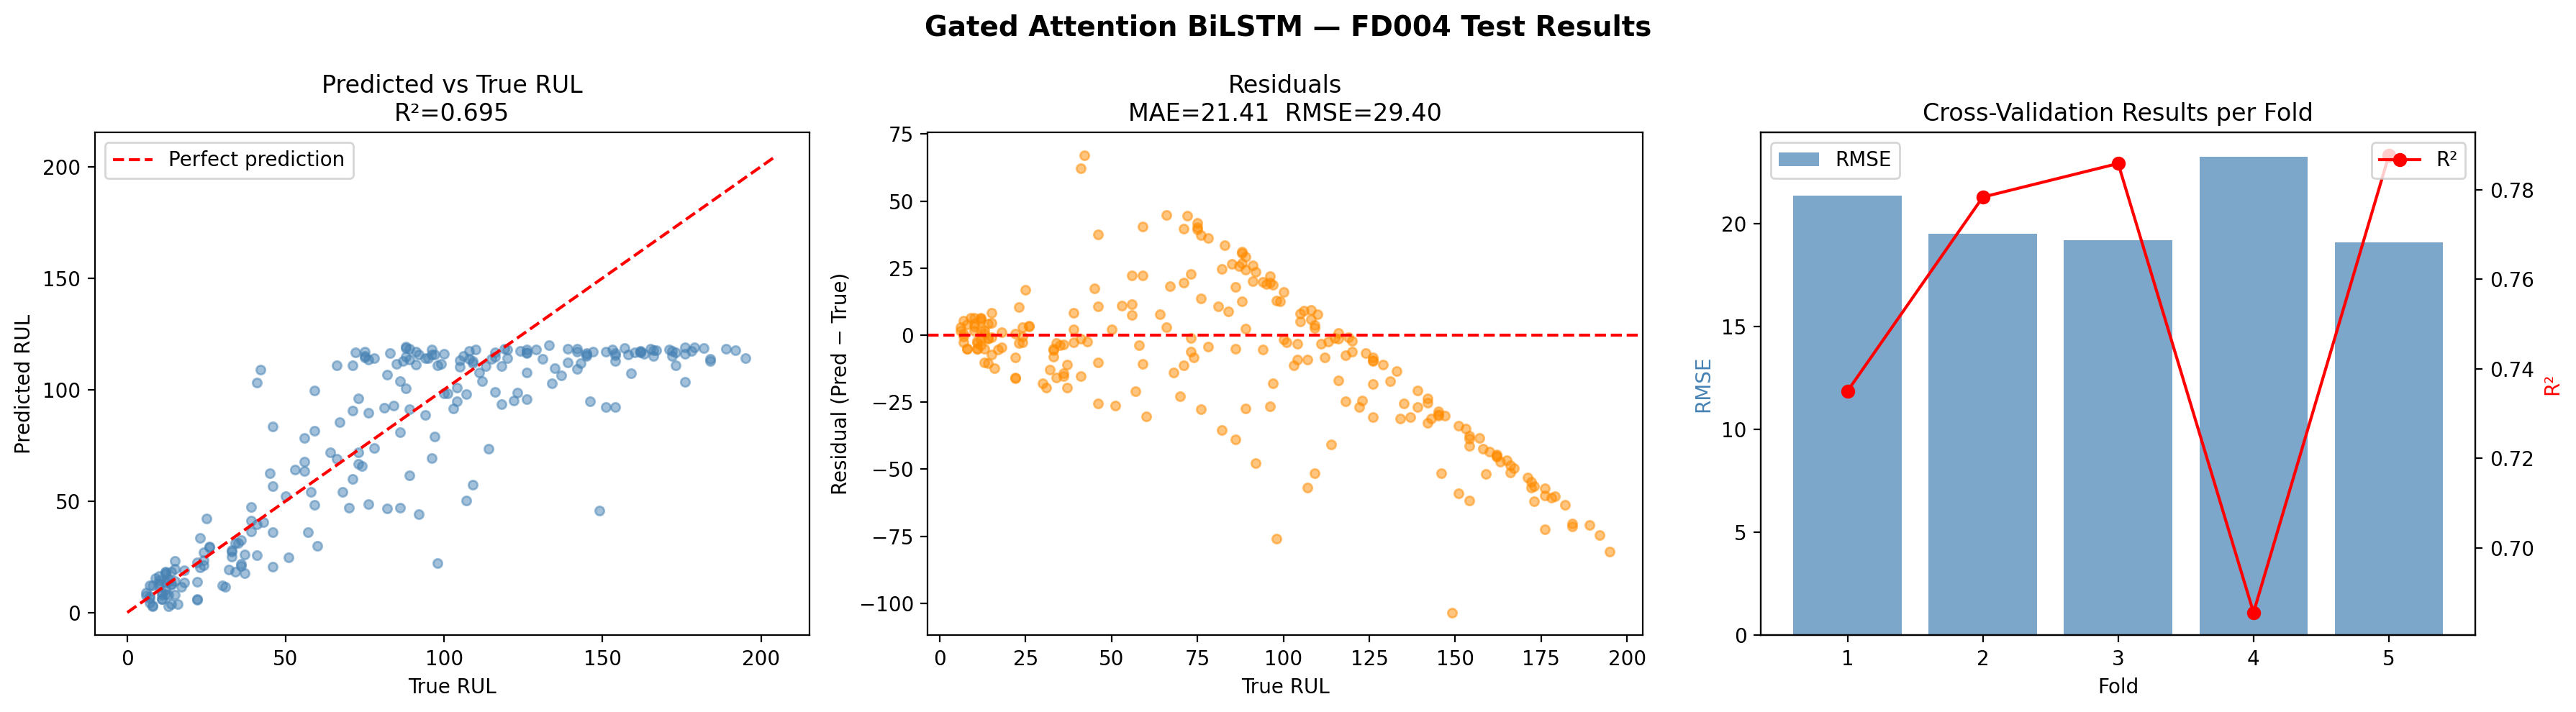

In [21]:
# ============================================================
# TEST SET EVALUATION + VISUALIZATIONS
# ============================================================

# Predict on all test sequences
y_test_pred_all = best_model.predict(X_test_seq, verbose=0).flatten()
y_test_pred_all = np.clip(y_test_pred_all, 0, None)  # RUL can't be negative

# Take the LAST window prediction per engine (closest to failure)
unique_engines = sorted(set(test_engine_ids))
y_true_list, y_pred_list = [], []

for eng_id in unique_engines:
    mask = test_engine_ids == eng_id
    y_pred_list.append(float(y_test_pred_all[mask][-1]))
    y_true_list.append(float(df_test_RUL.iloc[int(eng_id) - 1]['RUL']))

y_true = np.array(y_true_list)
y_pred = np.array(y_pred_list)

test_mae  = mean_absolute_error(y_true, y_pred)
test_rmse = np.sqrt(mean_squared_error(y_true, y_pred))
test_r2   = r2_score(y_true, y_pred)

print("=" * 45)
print("  FINAL TEST SET RESULTS")
print("=" * 45)
print(f"  MAE  : {test_mae:.4f}")
print(f"  RMSE : {test_rmse:.4f}")
print(f"  R²   : {test_r2:.4f}")
if test_r2 >= 0.85:
    print("\n  🏆 EXCELLENT PERFORMANCE ACHIEVED!")
elif test_r2 >= 0.75:
    print("\n  ✅ GOOD PERFORMANCE")
else:
    print("\n  ⚠️  Consider tuning cap value or window size")

# ── Visualizations ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Gated Attention BiLSTM — FD004 Test Results', fontsize=14, fontweight='bold')

# Plot 1: Predicted vs True
axes[0].scatter(y_true, y_pred, alpha=0.5, color='steelblue', s=20)
lim = max(y_true.max(), y_pred.max()) + 10
axes[0].plot([0, lim], [0, lim], 'r--', label='Perfect prediction')
axes[0].set_xlabel('True RUL')
axes[0].set_ylabel('Predicted RUL')
axes[0].set_title(f'Predicted vs True RUL\nR²={test_r2:.3f}')
axes[0].legend()

# Plot 2: Residuals
residuals = y_pred - y_true
axes[1].scatter(y_true, residuals, alpha=0.5, color='darkorange', s=20)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('True RUL')
axes[1].set_ylabel('Residual (Pred − True)')
axes[1].set_title(f'Residuals\nMAE={test_mae:.2f}  RMSE={test_rmse:.2f}')

# Plot 3: CV fold performance
fold_nums  = [r['fold'] for r in cv_results]
fold_rmses = [r['rmse'] for r in cv_results]
fold_r2s   = [r['r2']   for r in cv_results]
ax3b = axes[2].twinx()
axes[2].bar(fold_nums, fold_rmses, color='steelblue', alpha=0.7, label='RMSE')
ax3b.plot(fold_nums, fold_r2s, 'ro-', label='R²')
axes[2].set_xlabel('Fold')
axes[2].set_ylabel('RMSE', color='steelblue')
ax3b.set_ylabel('R²', color='red')
axes[2].set_title('Cross-Validation Results per Fold')
axes[2].legend(loc='upper left')
ax3b.legend(loc='upper right')

plt.tight_layout()
plt.savefig('model_results.png', dpi=150, bbox_inches='tight')
plt.show()